# ExtraaLearn Lead Conversion Prediction

## Machine Learning Classification Project

### Author
Rain Au-yeung

---

## Project Overview

ExtraaLearn is an early-stage EdTech startup that offers upskilling and reskilling programs in cutting-edge technologies. As the business grows, the company generates a large number of leads through its website, mobile application, marketing campaigns, referrals, and other channels.

However, not every lead converts into a paid customer. Since sales and marketing resources are limited, it is important for ExtraaLearn to identify which leads are more likely to convert. This enables the business to prioritize high-potential leads, improve conversion rates, and allocate resources more efficiently.

This project uses exploratory data analysis and machine learning classification models to predict whether a lead is likely to convert into a paid customer.

---

## Business Objective

The objectives of this project are to:

1. Analyze lead behavior and identify key factors associated with conversion.
2. Build machine learning models to predict whether a lead will convert.
3. Compare model performance and select the most suitable model.
4. Create a profile of leads that are most likely to convert.
5. Provide actionable business recommendations for improving lead conversion.

## Data Description

The dataset contains lead-level information and interaction details with ExtraaLearn.

### Data Dictionary

| Column | Description |
|---|---|
| `ID` | Unique ID of the lead |
| `age` | Age of the lead |
| `current_occupation` | Current occupation of the lead: Professional, Unemployed, or Student |
| `first_interaction` | First channel through which the lead interacted with ExtraaLearn: Website or Mobile App |
| `profile_completed` | Percentage of profile completed: Low, Medium, or High |
| `website_visits` | Number of times the lead visited the website |
| `time_spent_on_website` | Total time spent by the lead on the website |
| `page_views_per_visit` | Average number of pages viewed per website visit |
| `last_activity` | Most recent interaction between the lead and ExtraaLearn |
| `print_media_type1` | Whether the lead saw an ad in Newspaper |
| `print_media_type2` | Whether the lead saw an ad in Magazine |
| `digital_media` | Whether the lead saw an ad on digital platforms |
| `educational_channels` | Whether the lead heard about ExtraaLearn through educational channels |
| `referral` | Whether the lead heard about ExtraaLearn through a referral |
| `status` | Target variable; 1 indicates converted, 0 indicates not converted |

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, model building, model evaluation, and saving outputs.

In [27]:
# Install required libraries if running in a fresh environment
# You can skip this cell if the libraries are already installed.

# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [28]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import os

# Model building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Model persistence
import joblib

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Output Directory Setup

The following folders are created to save figures, reports, and trained models.

In [ ]:
# Create output folders
os.makedirs("../reports", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

## Loading the Dataset

The dataset is loaded from the `data` folder. The notebook assumes the following relative path:

`../data/Potential_Customers_Prediction.csv`

In [ ]:
# Load the dataset
data_path = "../data/Potential_Customers_Prediction.csv"
df = pd.read_csv(data_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [32]:
# Display the first five rows
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


## Data Overview

This section provides an initial understanding of the dataset, including its shape, data types, missing values, duplicate records, and summary statistics.

In [31]:
# Dataset shape
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset contains 4612 rows and 15 columns.


In [33]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   str    
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   str    
 3   first_interaction      4612 non-null   str    
 4   profile_completed      4612 non-null   str    
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   str    
 9   print_media_type1      4612 non-null   str    
 10  print_media_type2      4612 non-null   str    
 11  digital_media          4612 non-null   str    
 12  educational_channels   4612 non-null   str    
 13  referral               4612 non-null   str    
 14  status                 4612 non-null   int64  
dtypes: float64(1), 

In [34]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [35]:
# Summary statistics for categorical variables
df.describe(include="object").T

,count,unique,top,freq
ID,4612,4612,EXT001,1
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


In [36]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Check for missing values
missing_values = df.isnull().sum()
missing_values

Number of duplicate rows: 0


ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

In [ ]:
# Target variable distribution
target_summary = pd.DataFrame({
    "Count": df["status"].value_counts(),
    "Percentage": df["status"].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
status,,
0,3235,70.143105
1,1377,29.856895


### Observations

- The dataset contains **4,612 rows** and **15 columns**.
- There are **no missing values** in the dataset.
- There are **no duplicate records**.
- The target variable is `status`, where:
  - `1` indicates that the lead converted to a paid customer.
  - `0` indicates that the lead did not convert.
- Approximately **29.9%** of leads converted, while about **70.1%** did not convert.
- The dataset contains a mix of numerical, categorical, binary, and ordinal variables.
- The `ID` column is a unique identifier and will be removed before model training.

# Exploratory Data Analysis

The goal of exploratory data analysis is to understand patterns in lead behavior and identify factors that may influence conversion.

The analysis focuses on the following business questions:

1. How does current occupation affect lead conversion?
2. Does the first interaction channel influence conversion?
3. Which last activity type is most associated with conversion?
4. Which marketing channels have the highest conversion rates?
5. Does profile completion increase the likelihood of conversion?
6. How do website engagement metrics relate to conversion?

## Target Variable Distribution

Before analyzing predictors, it is useful to understand the distribution of the target variable.

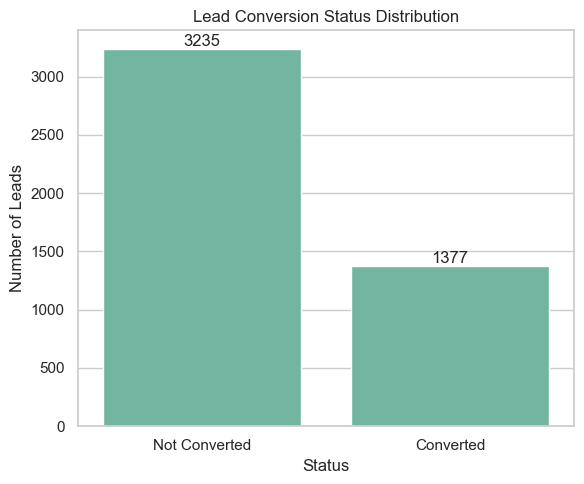

In [ ]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x="status")

plt.title("Lead Conversion Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Leads")
plt.xticks([0, 1], ["Not Converted", "Converted"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The dataset is moderately imbalanced. A larger proportion of leads did not convert compared to those who converted. This should be considered during model evaluation, as accuracy alone may not fully reflect model effectiveness.

## Current Occupation and Lead Conversion

Current occupation may influence a lead's motivation and ability to enroll in an upskilling or reskilling program.

In [ ]:
occupation_conversion = (
    df.groupby("current_occupation")["status"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Lead Count", "mean": "Conversion Rate"})
    .sort_values("Conversion Rate", ascending=False)
)

occupation_conversion["Conversion Rate"] = occupation_conversion["Conversion Rate"] * 100
occupation_conversion

,Lead Count,Conversion Rate
current_occupation,,
Professional,2616,35.512232
Unemployed,1441,26.578765
Student,555,11.711712


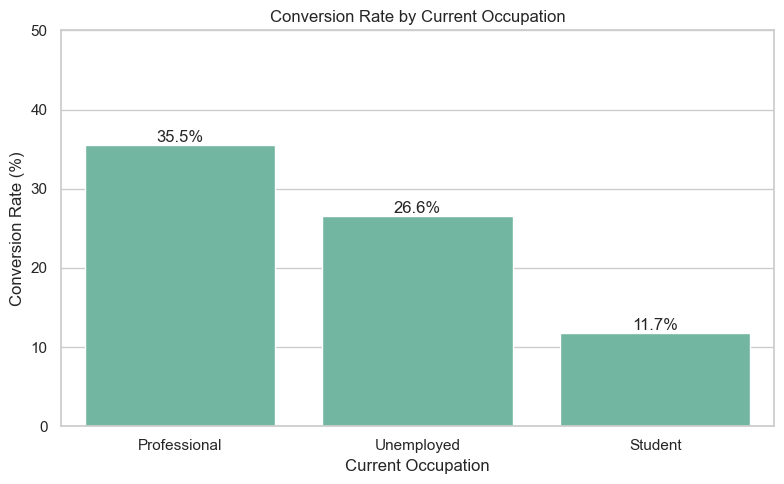

In [40]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=occupation_conversion.reset_index(),
    x="current_occupation",
    y="Conversion Rate"
)

plt.title("Conversion Rate by Current Occupation")
plt.xlabel("Current Occupation")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig("../reports/figures/conversion_by_occupation.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Professionals have the highest conversion rate among all occupation groups, followed by unemployed leads. Students have the lowest conversion rate.

This suggests that professionals are more likely to find immediate value in ExtraaLearn's upskilling or reskilling programs. They may also have stronger career advancement goals and greater ability to pay compared to students.

## First Interaction Channel and Lead Conversion

The first interaction channel represents the initial touchpoint between the lead and ExtraaLearn. This first impression may influence conversion likelihood.

In [ ]:
first_interaction_conversion = (
    df.groupby("first_interaction")["status"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Lead Count", "mean": "Conversion Rate"})
    .sort_values("Conversion Rate", ascending=False)
)

first_interaction_conversion["Conversion Rate"] = first_interaction_conversion["Conversion Rate"] * 100
first_interaction_conversion

,Lead Count,Conversion Rate
first_interaction,,
Website,2542,45.594020
Mobile App,2070,10.531401


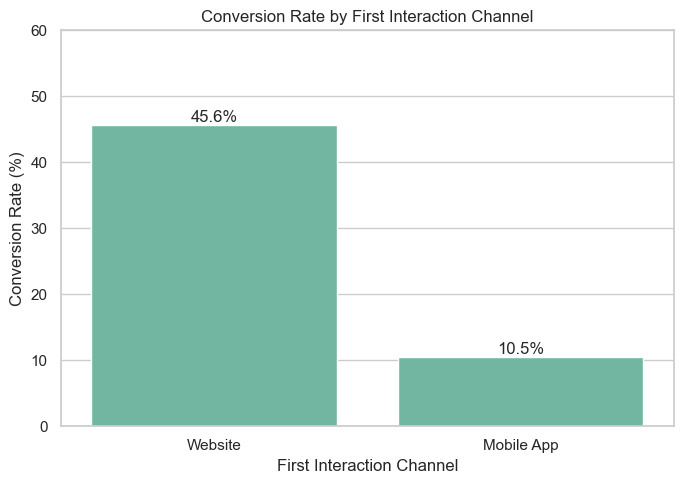

In [42]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=first_interaction_conversion.reset_index(),
    x="first_interaction",
    y="Conversion Rate"
)

plt.title("Conversion Rate by First Interaction Channel")
plt.xlabel("First Interaction Channel")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 60)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig("../reports/figures/conversion_by_first_interaction.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Leads whose first interaction was through the website have a much higher conversion rate than leads whose first interaction was through the mobile app.

This indicates that the website is a stronger first-touch channel for generating high-quality leads. The company should continue improving website content, navigation, landing pages, and calls to action.

## Last Activity and Lead Conversion

The last activity captures the most recent interaction between the lead and ExtraaLearn. This can provide insight into which interaction types are most associated with conversion.

In [ ]:
last_activity_conversion = (
    df.groupby("last_activity")["status"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Lead Count", "mean": "Conversion Rate"})
    .sort_values("Conversion Rate", ascending=False)
)

last_activity_conversion["Conversion Rate"] = last_activity_conversion["Conversion Rate"] * 100
last_activity_conversion

,Lead Count,Conversion Rate
last_activity,,
Website Activity,1100,38.454545
Email Activity,2278,30.333626
Phone Activity,1234,21.312804


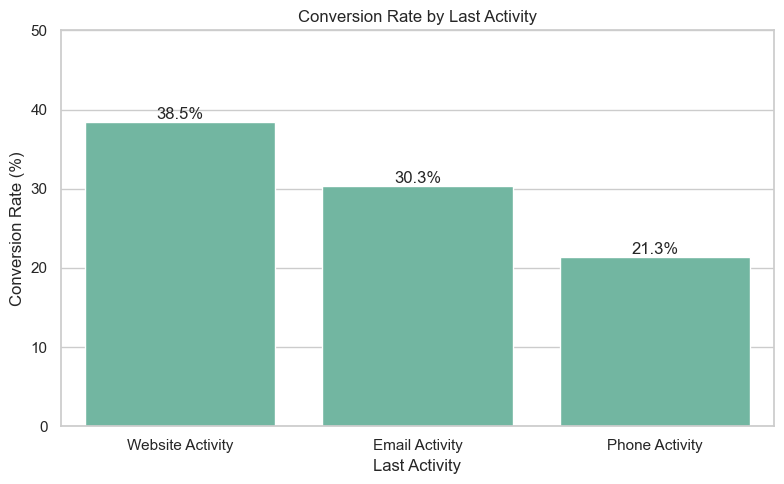

In [44]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=last_activity_conversion.reset_index(),
    x="last_activity",
    y="Conversion Rate"
)

plt.title("Conversion Rate by Last Activity")
plt.xlabel("Last Activity")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig("../reports/figures/conversion_by_last_activity.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Website Activity has the highest conversion rate among last activity types, followed by Email Activity and Phone Activity.

This suggests that leads who actively continue engaging with the website are more likely to convert. Website-based actions such as live chat interactions, profile updates, and continued browsing may indicate stronger purchase intent.

## Marketing Channel Conversion Rates

ExtraaLearn receives leads from multiple marketing channels. Comparing conversion rates across these channels helps identify the most effective acquisition sources.

In [45]:
channels = [
    "print_media_type1",
    "print_media_type2",
    "digital_media",
    "educational_channels",
    "referral"
]

channel_conversion_rates = []

for channel in channels:
    leads_from_channel = df[df[channel] == "Yes"]
    
    conversion_rate = leads_from_channel["status"].mean() * 100
    lead_count = leads_from_channel.shape[0]
    
    channel_conversion_rates.append({
        "Channel": channel,
        "Lead Count": lead_count,
        "Conversion Rate": conversion_rate
    })

channel_conversion_df = pd.DataFrame(channel_conversion_rates)
channel_conversion_df = channel_conversion_df.sort_values(
    "Conversion Rate",
    ascending=False
)

channel_conversion_df

,Channel,Lead Count,Conversion Rate
4,referral,93,67.741935
1,print_media_type2,233,32.188841
0,print_media_type1,497,31.991952
2,digital_media,527,31.878558
3,educational_channels,705,27.943262


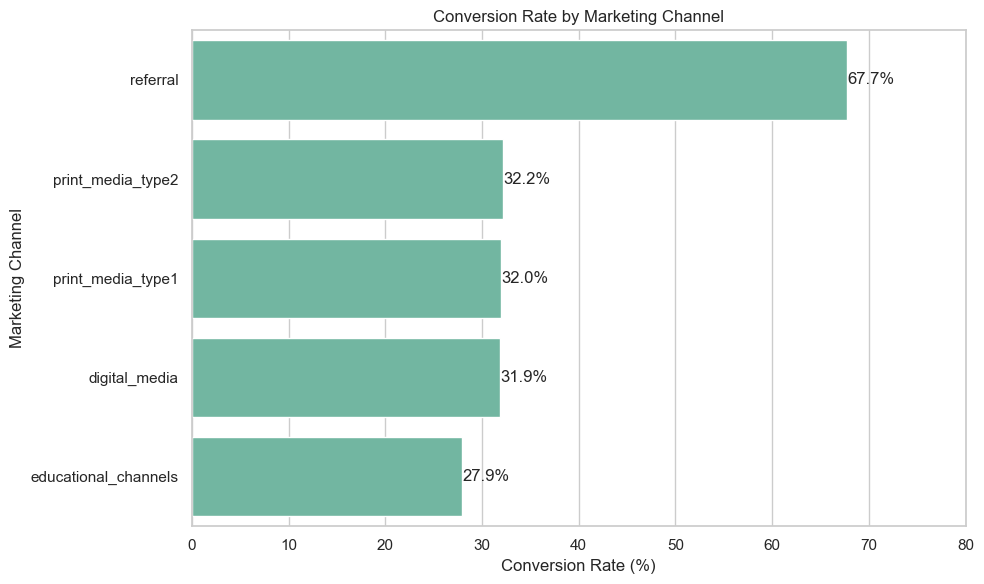

In [46]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=channel_conversion_df,
    x="Conversion Rate",
    y="Channel"
)

plt.title("Conversion Rate by Marketing Channel")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Marketing Channel")
plt.xlim(0, 80)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig("../reports/figures/conversion_by_marketing_channel.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Referral leads have the highest conversion rate among all marketing channels. Print media, digital media, and educational channels have lower conversion rates in comparison.

This suggests that referrals are a high-quality lead source. ExtraaLearn should consider strengthening its referral program and tracking referral performance more closely.

## Profile Completion and Lead Conversion

Profile completion can be interpreted as a proxy for user interest and commitment. Leads who provide more information may be more engaged and more likely to convert.

In [ ]:
profile_order = ["Low", "Medium", "High"]

profile_conversion = (
    df.groupby("profile_completed")["status"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Lead Count", "mean": "Conversion Rate"})
    .reindex(profile_order)
)

profile_conversion["Conversion Rate"] = profile_conversion["Conversion Rate"] * 100
profile_conversion

,Lead Count,Conversion Rate
profile_completed,,
Low,107,7.476636
Medium,2241,18.875502
High,2264,41.784452


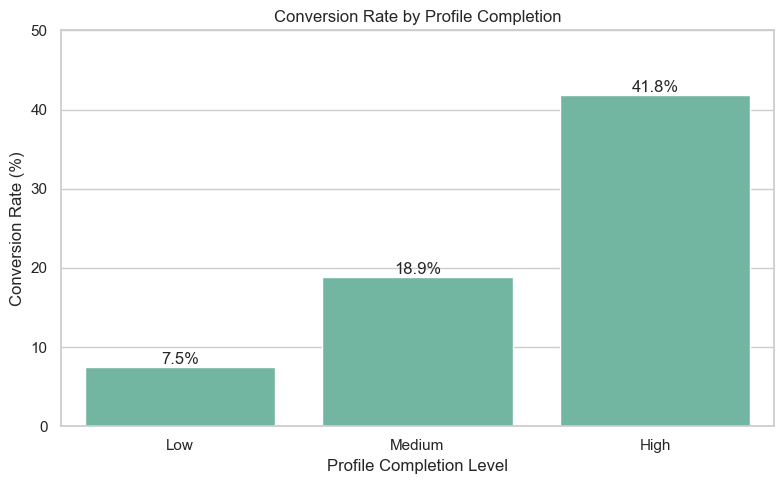

In [48]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=profile_conversion.reset_index(),
    x="profile_completed",
    y="Conversion Rate",
    order=profile_order
)

plt.title("Conversion Rate by Profile Completion")
plt.xlabel("Profile Completion Level")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig("../reports/figures/conversion_by_profile_completion.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

There is a strong positive relationship between profile completion and conversion.

Leads with high profile completion have the highest conversion rate, followed by leads with medium profile completion. Leads with low profile completion have the lowest conversion rate.

This suggests that profile completion is a useful indicator of engagement and intent.

## Website Engagement Metrics

Website behavior can reveal how interested a lead is in ExtraaLearn's programs. This section explores numerical engagement variables such as website visits, time spent on the website, and page views per visit.

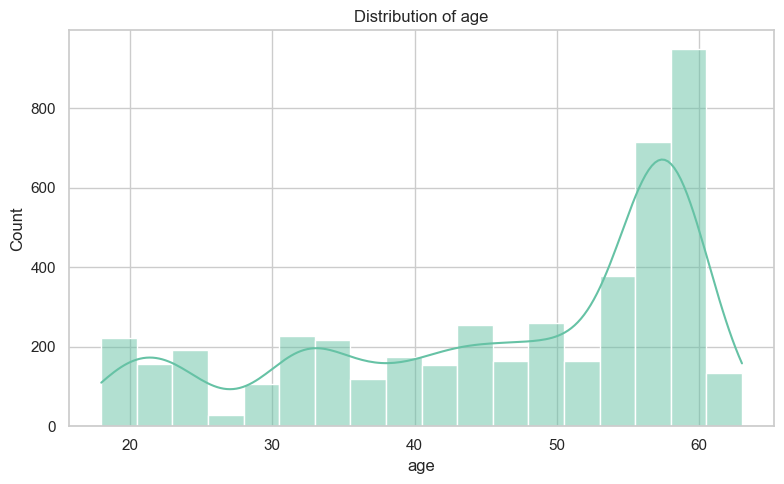

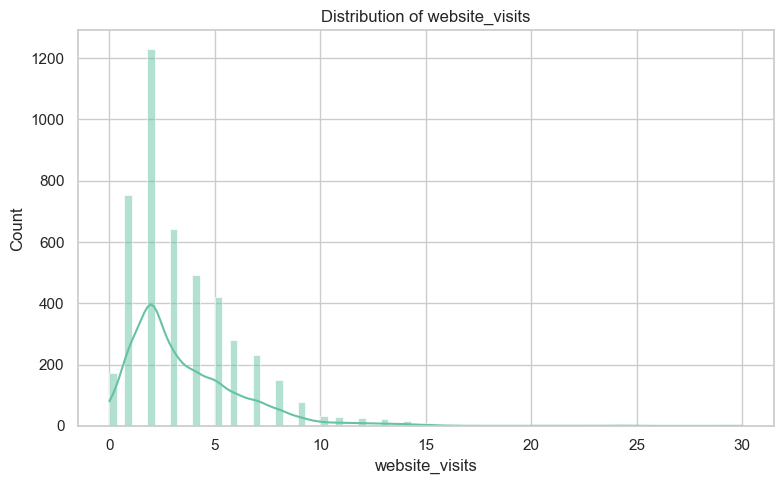

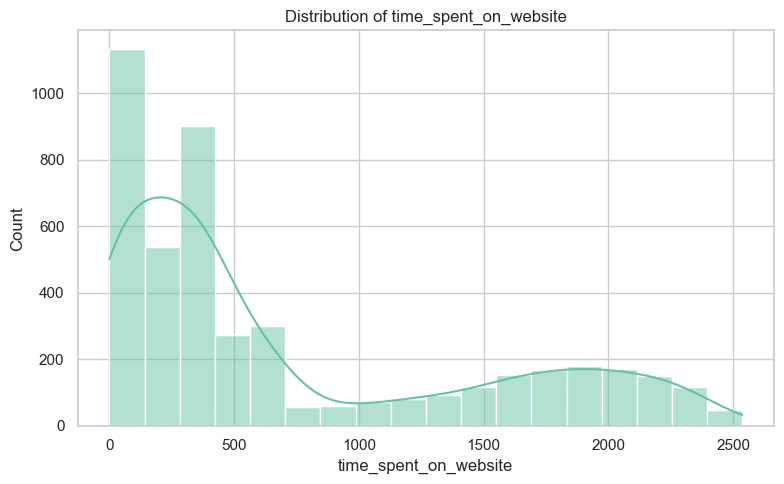

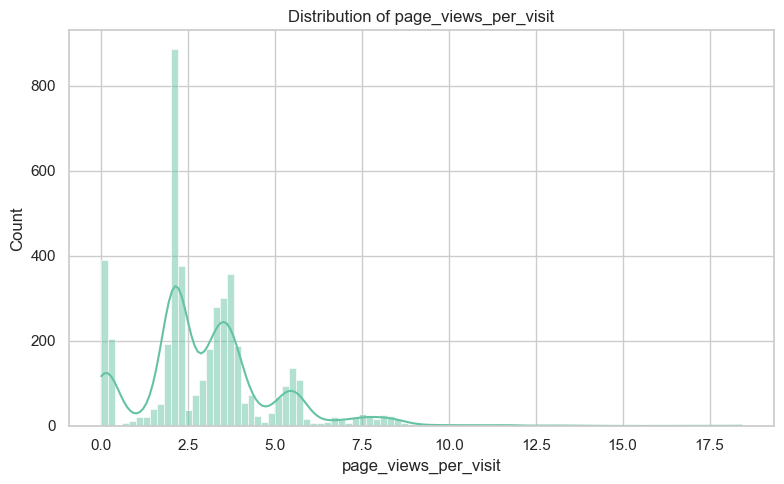

In [49]:
numeric_features = [
    "age",
    "website_visits",
    "time_spent_on_website",
    "page_views_per_visit"
]

for col in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(data=df, x=col, kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.savefig(f"../reports/figures/distribution_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

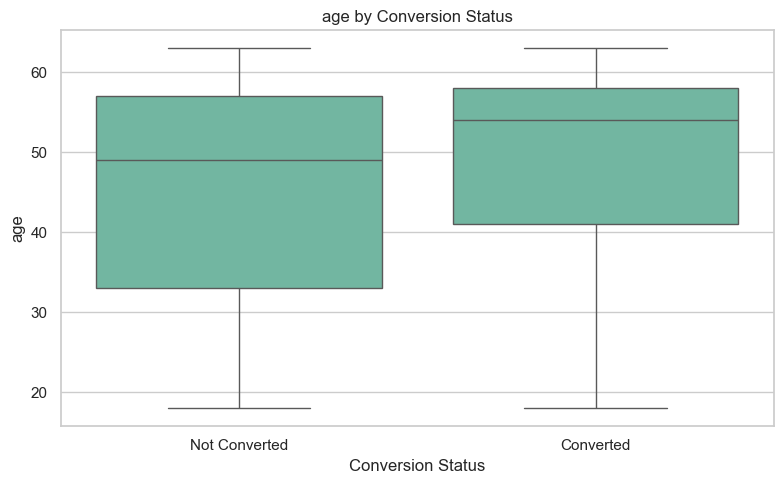

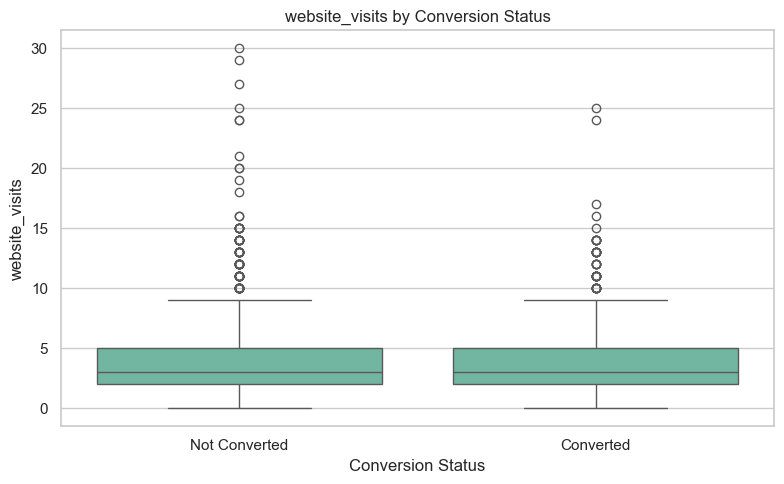

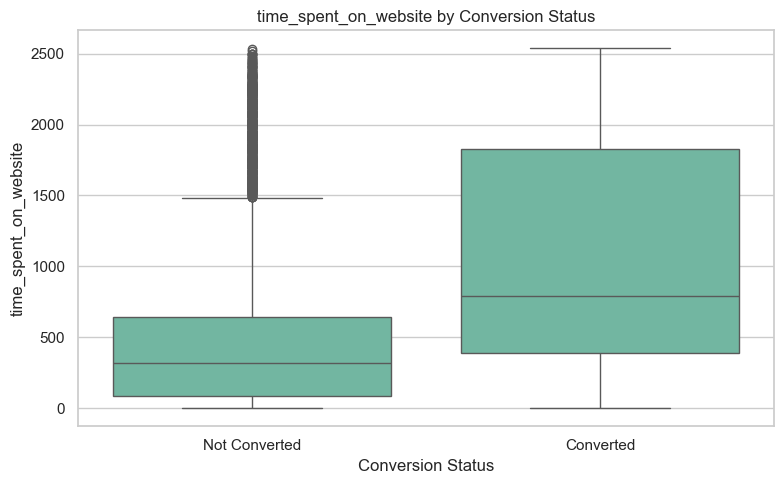

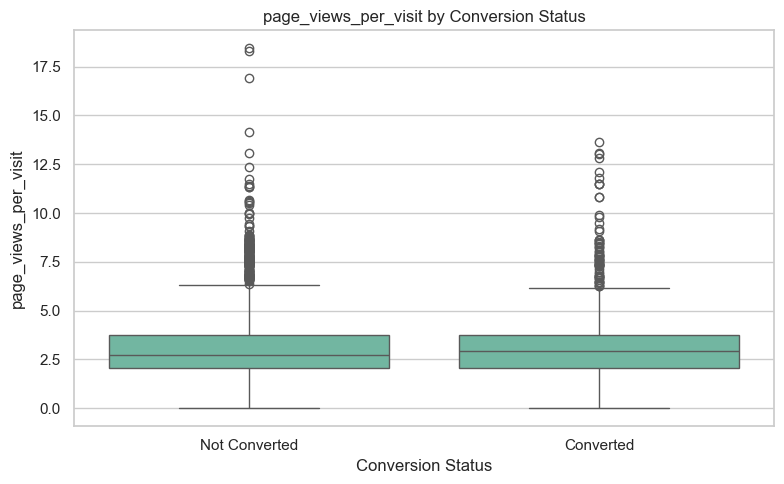

In [50]:
for col in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(data=df, x="status", y=col)
    
    plt.title(f"{col} by Conversion Status")
    plt.xlabel("Conversion Status")
    plt.ylabel(col)
    plt.xticks([0, 1], ["Not Converted", "Converted"])
    
    plt.tight_layout()
    plt.savefig(f"../reports/figures/boxplot_{col}_by_status.png", dpi=300, bbox_inches="tight")
    plt.show()

### Observation

Website engagement metrics such as time spent on the website, number of visits, and page views per visit appear to be useful indicators of conversion intent.

Leads who spend more time exploring the website and interact more deeply with online content are more likely to be interested in the programs offered by ExtraaLearn.

# Data Preprocessing

Before building machine learning models, the dataset must be prepared by:

1. Removing non-predictive identifiers.
2. Separating features and target variable.
3. Encoding categorical variables.
4. Splitting the data into training and testing sets.

In [51]:
# Create a copy of the data
df_processed = df.copy()

In [52]:
# Drop ID column because it is a unique identifier and does not contribute to prediction
df_processed = df_processed.drop("ID", axis=1)

In [53]:
# Separate features and target
X = df_processed.drop("status", axis=1)
y = df_processed["status"]

In [ ]:
# Encode ordinal variable: profile_completed
profile_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

X["profile_completed"] = X["profile_completed"].map(profile_mapping)

In [54]:
# Encode binary Yes/No variables
binary_cols = [
    "print_media_type1",
    "print_media_type2",
    "digital_media",
    "educational_channels",
    "referral"
]

for col in binary_cols:
    X[col] = X[col].map({
        "No": 0,
        "Yes": 1
    })

In [ ]:
# One-hot encode nominal categorical variables
X = pd.get_dummies(
    X,
    columns=[
        "current_occupation",
        "first_interaction",
        "last_activity"
    ],
    drop_first=True,
    dtype=int
)

In [56]:
# Display processed data
X.head()

,age,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,last_activity_Phone Activity,last_activity_Website Activity
0,57,High,7,1639,1.861,1,0,1,0,0,0,1,1,0,1
1,56,Medium,2,83,0.320,0,0,0,1,0,0,0,0,0,1
2,52,Medium,3,330,0.074,0,0,1,0,0,0,0,1,0,1
3,53,High,4,464,2.057,0,0,0,0,0,0,1,1,0,1
4,23,High,4,600,16.914,0,0,0,0,0,1,0,1,0,0


In [57]:
# Check final feature columns
X.columns.tolist()

['age',
 'profile_completed',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral',
 'current_occupation_Student',
 'current_occupation_Unemployed',
 'first_interaction_Website',
 'last_activity_Phone Activity',
 'last_activity_Website Activity']

## Correlation Analysis

A correlation matrix is used to check whether strong linear relationships exist among the processed independent variables.

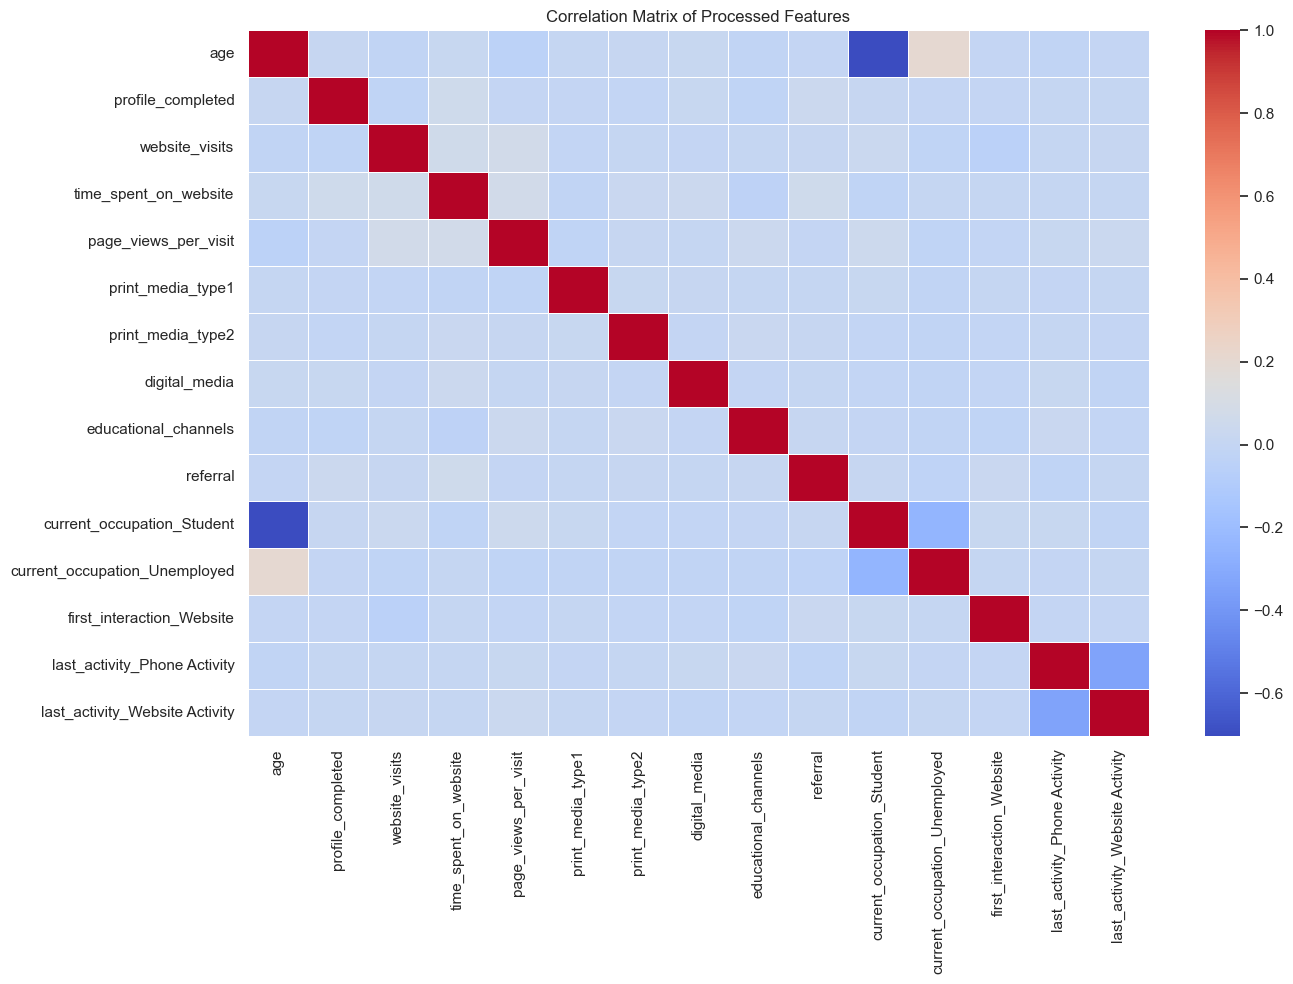

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix of Processed Features")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The processed features do not show severe multicollinearity. Since tree-based models are also relatively robust to correlated predictors, the dataset is suitable for Decision Tree and Random Forest modeling.

## Train-Test Split

The dataset is split into training and testing sets using a 70:30 ratio.

Stratified sampling is used to preserve the proportion of converted and non-converted leads in both sets.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3228, 15)
X_test shape: (1384, 15)
y_train shape: (3228,)
y_test shape: (1384,)


In [63]:
print("Training target distribution:")
display(y_train.value_counts(normalize=True))

print("Testing target distribution:")
display(y_test.value_counts(normalize=True))

Training target distribution:


status
0    0.701363
1    0.298637
Name: proportion, dtype: float64

Testing target distribution:


status
0    0.70159
1    0.29841
Name: proportion, dtype: float64

# Model Building and Evaluation

The models are evaluated using the following metrics:

| Metric | Meaning |
|---|---|
| Accuracy | Overall percentage of correct predictions |
| Recall | Ability to identify converted leads correctly |
| Precision | Percentage of predicted conversions that actually converted |
| F1 Score | Harmonic mean of precision and recall |

Because the business goal is to identify likely converters while balancing false positives and false negatives, the **F1 score** is used as an important model selection metric.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):

    #Computes classification performance metrics and displays a confusion matrix.

    pred = model.predict(predictors)
    
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    
    performance_df = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1 Score": f1
        },
        index=[0]
    )
    
    cm = confusion_matrix(target, pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Converted", "Converted"]
    )
    
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()
    
    return performance_df

In [ ]:
def get_model_metrics(model, predictors, target):

    #Returns classification metrics without plotting.

    
    pred = model.predict(predictors)
    
    return {
        "Accuracy": accuracy_score(target, pred),
        "Recall": recall_score(target, pred),
        "Precision": precision_score(target, pred),
        "F1 Score": f1_score(target, pred)
    }

## Decision Tree Classifier

A Decision Tree model is built first as a baseline interpretable model. Decision Trees are easy to interpret but can overfit if not properly regularized.

In [ ]:
# Build Decision Tree model
d_tree = DecisionTreeClassifier(random_state=42)
d_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Decision Tree Performance - Training Set


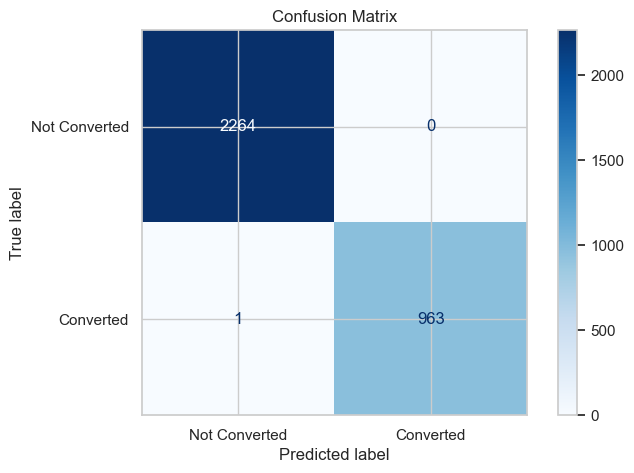

,Accuracy,Recall,Precision,F1 Score
0,0.99969,0.998963,1.0,0.999481


In [ ]:
# Training performance
print("Decision Tree Performance - Training Set")

d_tree_train_perf = model_performance_classification_sklearn(
    d_tree,
    X_train,
    y_train
)

d_tree_train_perf

Decision Tree Performance - Testing Set


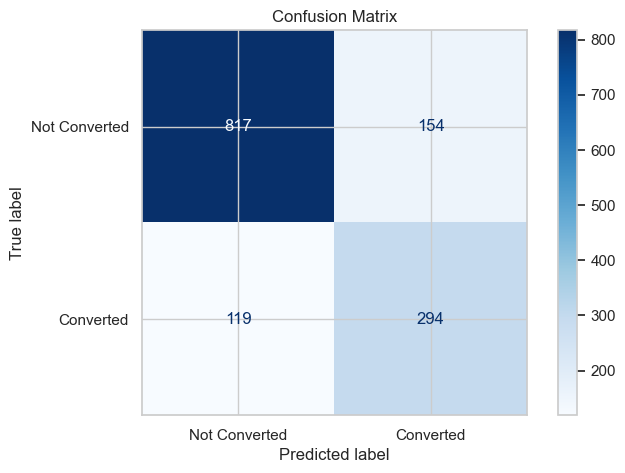

,Accuracy,Recall,Precision,F1 Score
0,0.802746,0.711864,0.65625,0.682927


In [ ]:
# Testing performance
print("Decision Tree Performance - Testing Set")

d_tree_test_perf = model_performance_classification_sklearn(
    d_tree,
    X_test,
    y_test
)

d_tree_test_perf

### Observation

The initial Decision Tree performs almost perfectly on the training set but performs noticeably worse on the testing set.

This indicates overfitting. The model is likely learning noise and very specific patterns in the training data rather than generalizable decision rules.

## Decision Tree Pruning

Cost-complexity pruning is applied to reduce overfitting. The pruning parameter `ccp_alpha` controls the trade-off between tree complexity and predictive performance.

In [ ]:
# Get cost-complexity pruning path
path = d_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of alpha values:", len(ccp_alphas))

Number of alpha values: 181


In [ ]:
# Train Decision Trees for different alpha values
clfs = []

for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=ccp_alpha
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [71]:
# Calculate train and test accuracy for each alpha
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

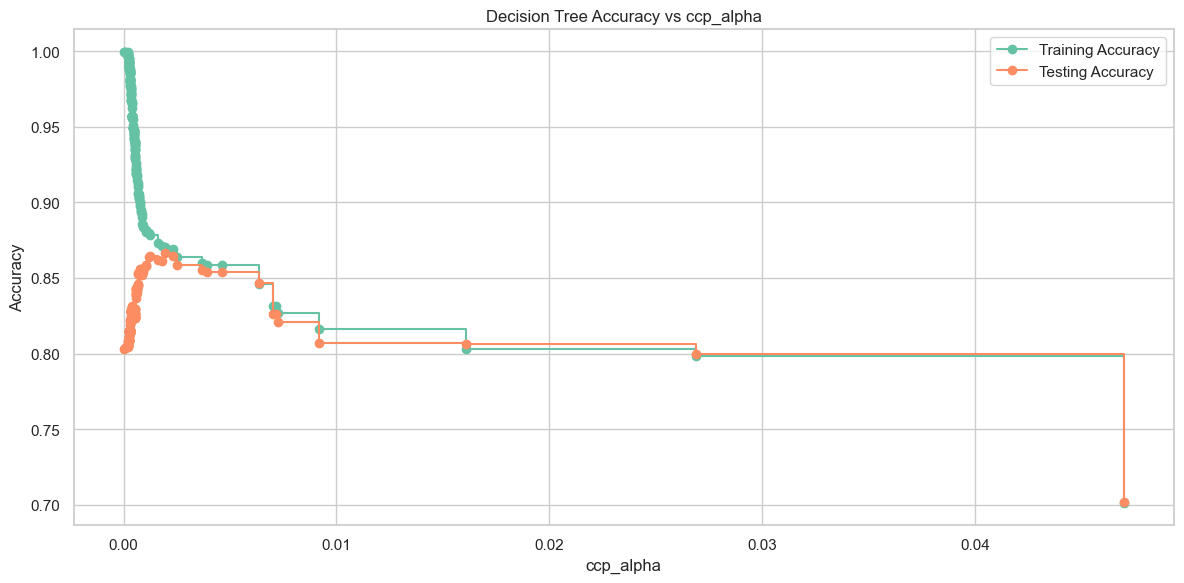

In [72]:
# Plot accuracy against alpha
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree Accuracy vs ccp_alpha")

ax.plot(
    ccp_alphas[:-1],
    train_scores[:-1],
    marker="o",
    label="Training Accuracy",
    drawstyle="steps-post"
)

ax.plot(
    ccp_alphas[:-1],
    test_scores[:-1],
    marker="o",
    label="Testing Accuracy",
    drawstyle="steps-post"
)

ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/decision_tree_pruning_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
# Select best alpha based on testing accuracy
best_alpha_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_alpha_index]

print(f"Best ccp_alpha: {best_alpha}")

Best ccp_alpha: 0.001958668105688131


In [74]:
# Build pruned Decision Tree
d_tree_pruned = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

d_tree_pruned.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Pruned Decision Tree Performance - Training Set


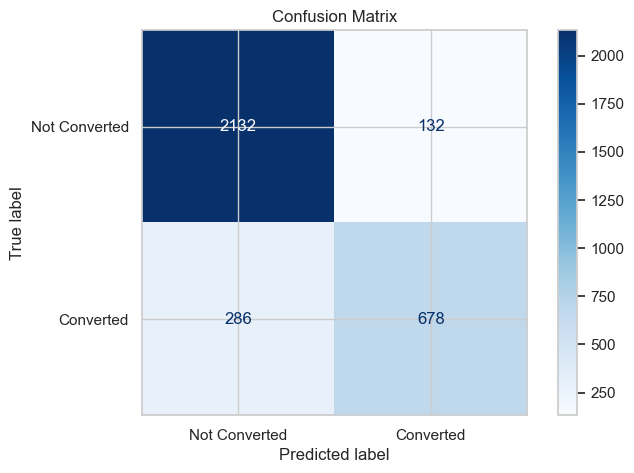

,Accuracy,Recall,Precision,F1 Score
0,0.870508,0.70332,0.837037,0.764374


In [75]:
# Training performance of pruned tree
print("Pruned Decision Tree Performance - Training Set")

d_tree_pruned_train_perf = model_performance_classification_sklearn(
    d_tree_pruned,
    X_train,
    y_train
)

d_tree_pruned_train_perf

Pruned Decision Tree Performance - Testing Set


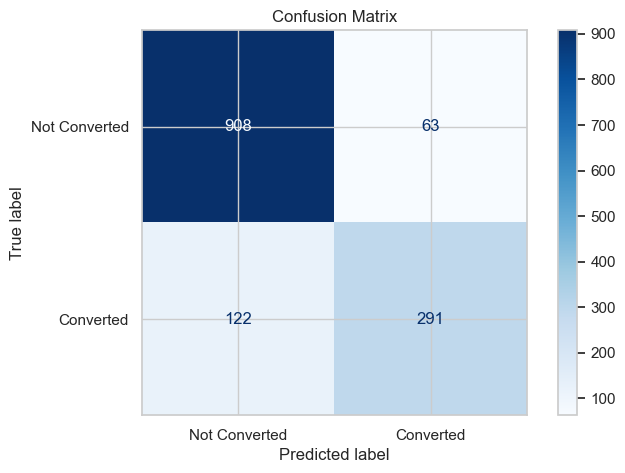

,Accuracy,Recall,Precision,F1 Score
0,0.866329,0.7046,0.822034,0.758801


In [76]:
# Testing performance of pruned tree
print("Pruned Decision Tree Performance - Testing Set")

d_tree_pruned_test_perf = model_performance_classification_sklearn(
    d_tree_pruned,
    X_test,
    y_test
)

d_tree_pruned_test_perf

### Observation

After pruning, the Decision Tree becomes less complex and generalizes better to unseen data.

The training performance decreases, which is expected, but the testing performance improves. This confirms that pruning helped reduce overfitting.

## Random Forest Classifier

Random Forest is an ensemble model that combines multiple Decision Trees. It usually provides stronger predictive performance and better generalization than a single Decision Tree.

In [ ]:
# Build Random Forest model
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Random Forest Performance - Training Set


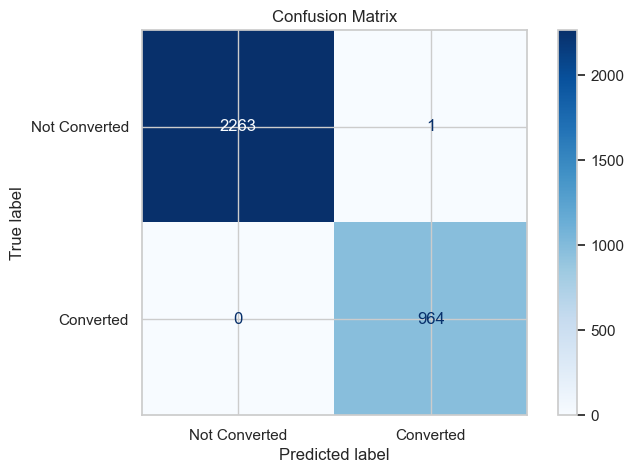

,Accuracy,Recall,Precision,F1 Score
0,0.99969,1.0,0.998964,0.999482


In [78]:
# Training performance
print("Random Forest Performance - Training Set")

rf_train_perf = model_performance_classification_sklearn(
    rf_clf,
    X_train,
    y_train
)

rf_train_perf

Random Forest Performance - Testing Set


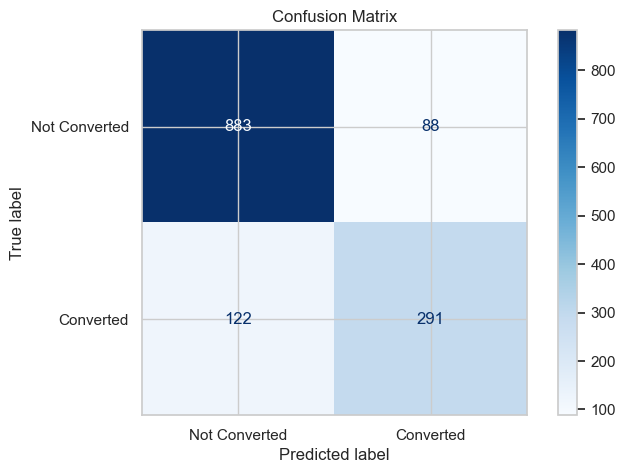

,Accuracy,Recall,Precision,F1 Score
0,0.848266,0.7046,0.76781,0.734848


In [79]:
# Testing performance
print("Random Forest Performance - Testing Set")

rf_test_perf = model_performance_classification_sklearn(
    rf_clf,
    X_test,
    y_test
)

rf_test_perf

### Observation

The default Random Forest model performs very well on the training set but shows a performance drop on the testing set.

This suggests some overfitting, although the model is generally stronger than the unpruned Decision Tree. Hyperparameter tuning is performed to improve generalization.

## Random Forest Hyperparameter Tuning

GridSearchCV is used to tune the Random Forest model. The search is performed using 5-fold cross-validation.

The following hyperparameters are tuned:

- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_leaf`: Minimum number of samples required at a leaf node
- `max_features`: Number of features considered when looking for the best split

In [80]:
# Define parameter grid
param_grid = {
    "n_estimators": [150, 200, 250],
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [2, 3, 5],
    "max_features": ["sqrt", 0.7]
}

In [81]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

In [82]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [2, 3, ...], 'n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [83]:
# Best parameters
print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}


In [84]:
# Get tuned model
rf_tuned = grid_search.best_estimator_

Tuned Random Forest Performance - Training Set


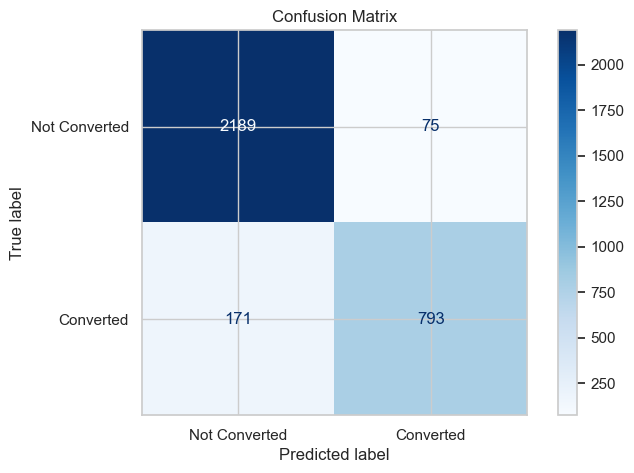

,Accuracy,Recall,Precision,F1 Score
0,0.923792,0.822614,0.913594,0.865721


In [85]:
# Training performance
print("Tuned Random Forest Performance - Training Set")

rf_tuned_train_perf = model_performance_classification_sklearn(
    rf_tuned,
    X_train,
    y_train
)

rf_tuned_train_perf

Tuned Random Forest Performance - Testing Set


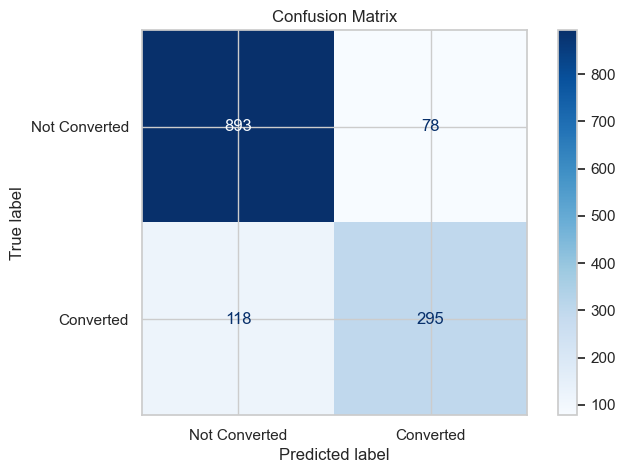

,Accuracy,Recall,Precision,F1 Score
0,0.858382,0.714286,0.790885,0.750636


In [86]:
# Testing performance

print("Tuned Random Forest Performance - Testing Set")

rf_tuned_test_perf = model_performance_classification_sklearn(
    rf_tuned,
    X_test,
    y_test
)

rf_tuned_test_perf

### Observation

After hyperparameter tuning, the Random Forest model becomes less overfit and achieves a strong balance between training and testing performance.

The tuned Random Forest is expected to be a strong candidate for the final model.

# Model Comparison

The models are compared using both training and testing metrics. The testing metrics are more important because they represent performance on unseen data.

In [87]:
# Build model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Pruned Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Train Accuracy": [
        d_tree_train_perf["Accuracy"].iloc[0],
        d_tree_pruned_train_perf["Accuracy"].iloc[0],
        rf_train_perf["Accuracy"].iloc[0],
        rf_tuned_train_perf["Accuracy"].iloc[0]
    ],
    "Train Recall": [
        d_tree_train_perf["Recall"].iloc[0],
        d_tree_pruned_train_perf["Recall"].iloc[0],
        rf_train_perf["Recall"].iloc[0],
        rf_tuned_train_perf["Recall"].iloc[0]
    ],
    "Train Precision": [
        d_tree_train_perf["Precision"].iloc[0],
        d_tree_pruned_train_perf["Precision"].iloc[0],
        rf_train_perf["Precision"].iloc[0],
        rf_tuned_train_perf["Precision"].iloc[0]
    ],
    "Train F1 Score": [
        d_tree_train_perf["F1 Score"].iloc[0],
        d_tree_pruned_train_perf["F1 Score"].iloc[0],
        rf_train_perf["F1 Score"].iloc[0],
        rf_tuned_train_perf["F1 Score"].iloc[0]
    ],
    "Test Accuracy": [
        d_tree_test_perf["Accuracy"].iloc[0],
        d_tree_pruned_test_perf["Accuracy"].iloc[0],
        rf_test_perf["Accuracy"].iloc[0],
        rf_tuned_test_perf["Accuracy"].iloc[0]
    ],
    "Test Recall": [
        d_tree_test_perf["Recall"].iloc[0],
        d_tree_pruned_test_perf["Recall"].iloc[0],
        rf_test_perf["Recall"].iloc[0],
        rf_tuned_test_perf["Recall"].iloc[0]
    ],
    "Test Precision": [
        d_tree_test_perf["Precision"].iloc[0],
        d_tree_pruned_test_perf["Precision"].iloc[0],
        rf_test_perf["Precision"].iloc[0],
        rf_tuned_test_perf["Precision"].iloc[0]
    ],
    "Test F1 Score": [
        d_tree_test_perf["F1 Score"].iloc[0],
        d_tree_pruned_test_perf["F1 Score"].iloc[0],
        rf_test_perf["F1 Score"].iloc[0],
        rf_tuned_test_perf["F1 Score"].iloc[0]
    ]
})

model_comparison

,Model,Train Accuracy,Train Recall,Train Precision,Train F1 Score,Test Accuracy,Test Recall,Test Precision,Test F1 Score
0,Decision Tree,0.999690,0.998963,1.000000,0.999481,0.802746,0.711864,0.656250,0.682927
1,Pruned Decision Tree,0.870508,0.703320,0.837037,0.764374,0.866329,0.704600,0.822034,0.758801
2,Random Forest,0.999690,1.000000,0.998964,0.999482,0.848266,0.704600,0.767810,0.734848
3,Tuned Random Forest,0.923792,0.822614,0.913594,0.865721,0.858382,0.714286,0.790885,0.750636


In [88]:
# Save model comparison table
model_comparison.to_csv("../reports/model_comparison.csv", index=False)

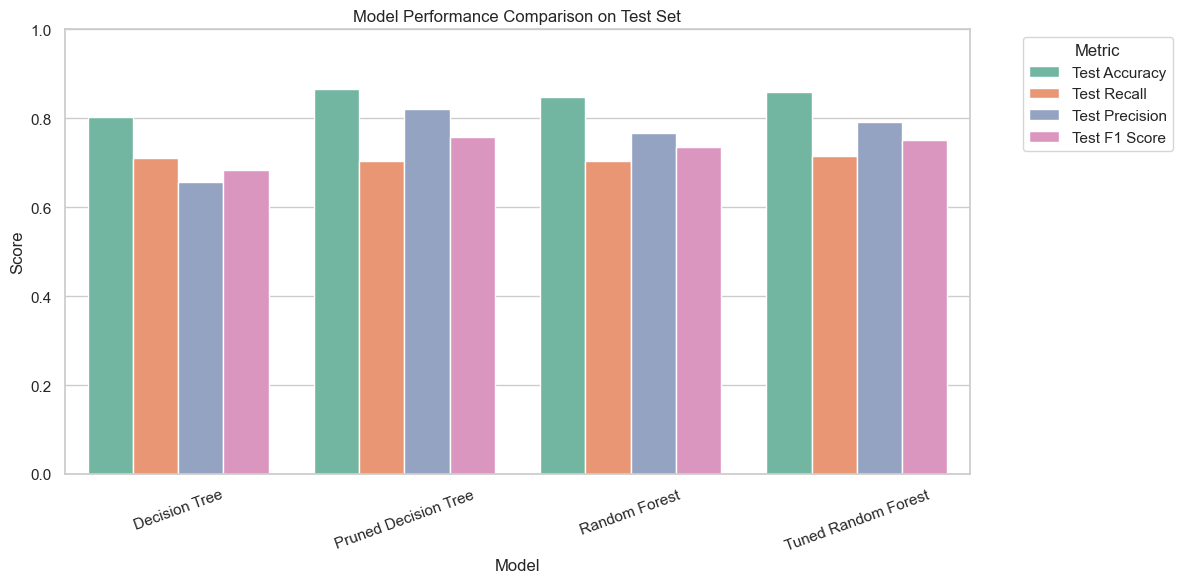

In [89]:
# Visualize test metrics
model_comparison_melted = model_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Test Accuracy",
        "Test Recall",
        "Test Precision",
        "Test F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=model_comparison_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Final Model Selection

The final model is selected based on the highest test F1 score. F1 score is appropriate because it balances precision and recall, both of which are important in lead conversion prediction.

- A false positive means the sales team may spend time on a lead that does not convert.
- A false negative means the company may miss a high-potential lead.

In [90]:
# Select model with highest test F1 score
best_model_row = model_comparison.sort_values(
    by="Test F1 Score",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]

print(f"Best model based on Test F1 Score: {best_model_name}")

Best model based on Test F1 Score: Pruned Decision Tree


In [91]:
# Assign final model
if best_model_name == "Decision Tree":
    final_model = d_tree
elif best_model_name == "Pruned Decision Tree":
    final_model = d_tree_pruned
elif best_model_name == "Random Forest":
    final_model = rf_clf
else:
    final_model = rf_tuned

final_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [92]:
# Final model classification report
final_predictions = final_model.predict(X_test)

print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       971
           1       0.82      0.70      0.76       413

    accuracy                           0.87      1384
   macro avg       0.85      0.82      0.83      1384
weighted avg       0.86      0.87      0.86      1384



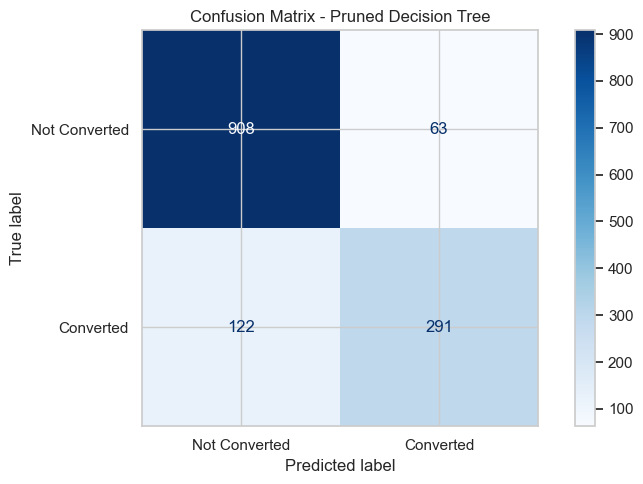

In [93]:
# Final model confusion matrix
cm = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Converted", "Converted"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - {best_model_name}")

plt.tight_layout()
plt.savefig("../reports/figures/final_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Final Model Summary

Based on the model comparison, the selected final model provides the best balance between precision and recall on the testing data.

This model can be used by ExtraaLearn as a lead scoring tool to prioritize leads with a higher probability of conversion.

# Feature Importance Analysis

Feature importance helps identify the variables that contribute most to the model's predictions.

For tree-based models, feature importance is calculated based on how much each feature reduces impurity across the trees.

In [94]:
# Feature importance from final model
if hasattr(final_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": final_model.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    display(feature_importance_df.head(15))
else:
    print("The final model does not support feature importance.")

,Feature,Importance
12,first_interaction_Website,0.353524
3,time_spent_on_website,0.258032
1,profile_completed,0.150769
13,last_activity_Phone Activity,0.069881
11,current_occupation_Unemployed,0.058697
0,age,0.046656
10,current_occupation_Student,0.031424
14,last_activity_Website Activity,0.031016
2,website_visits,0.000000
4,page_views_per_visit,0.000000


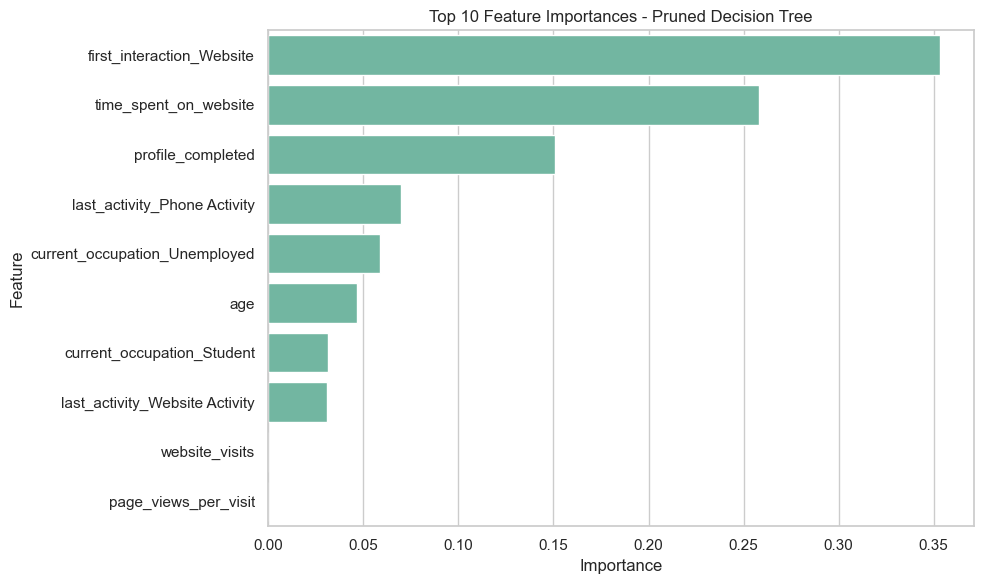

In [95]:
# Plot top 10 important features
if hasattr(final_model, "feature_importances_"):
    top_10_features = feature_importance_df.head(10)
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        data=top_10_features,
        x="Importance",
        y="Feature"
    )
    
    plt.title(f"Top 10 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    
    plt.tight_layout()
    plt.savefig("../reports/figures/final_model_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

### Key Drivers of Lead Conversion

Based on the feature importance analysis, the most influential factors are expected to include:

1. **Time spent on website**
2. **Age**
3. **Profile completion**
4. **Page views per visit**
5. **Website visits**
6. **First interaction through website**
7. **Occupation**
8. **Last activity**
9. **Referral source**

These factors suggest that user engagement, demographic profile, and acquisition source are important indicators of lead conversion.

# Saving Model Artifacts

The final trained model and preprocessing information are saved so that they can be reused for future predictions.

In [96]:
# Save final model
joblib.dump(final_model, "../models/final_model.joblib")

print("Final model saved successfully.")

Final model saved successfully.


In [97]:
# Save feature columns
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "../models/feature_columns.joblib")

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [98]:
# Save preprocessing information
preprocessing_info = {
    "profile_mapping": profile_mapping,
    "binary_columns": binary_cols,
    "one_hot_encoded_columns": [
        "current_occupation",
        "first_interaction",
        "last_activity"
    ],
    "feature_columns": feature_columns
}

joblib.dump(preprocessing_info, "../models/preprocessing_info.joblib")

print("Preprocessing information saved successfully.")

Preprocessing information saved successfully.


# Business Insights

The analysis reveals several important patterns in lead conversion behavior.

### 1. Professionals are the strongest occupation segment

Professionals have the highest conversion rate among the occupation groups. This suggests that working individuals may have stronger motivation to upskill or reskill and may be more willing to invest in paid learning programs.

### 2. Website-first leads convert better

Leads whose first interaction occurs through the website have a substantially higher conversion rate than leads who first interact through the mobile app. This indicates that the website plays an important role in building trust and communicating program value.

### 3. Website engagement is highly predictive

Time spent on the website, page views per visit, and website visits are among the most important predictors. This suggests that leads who actively explore the website demonstrate stronger purchase intent.

### 4. Profile completion indicates commitment

Leads with high profile completion are much more likely to convert. Completing a profile likely reflects stronger interest, trust, and willingness to engage with the platform.

### 5. Referrals generate high-quality leads

Referral leads have the highest conversion rate among the marketing channels. This indicates that word-of-mouth and trusted recommendations are valuable sources of high-intent leads.

### 6. Tuned tree-based models can support lead prioritization

The final model can be used to estimate lead conversion probability and support sales prioritization.

# Recommendations

Based on the analysis and model results, the following actions are recommended for ExtraaLearn.

### 1. Prioritize professional leads

ExtraaLearn should focus marketing and sales efforts on professionals, as this group has the highest conversion rate. Campaigns can be targeted through professional platforms, career communities, and industry-specific channels.

### 2. Improve and optimize the website experience

Since website interactions are strongly associated with conversion, ExtraaLearn should continue improving its website experience. This includes:

- Clear program descriptions
- Strong calls to action
- Learner testimonials
- Career outcome information
- Live chat support
- Personalized course recommendations

### 3. Encourage profile completion

ExtraaLearn should motivate users to complete their profiles by offering benefits such as:

- Personalized course suggestions
- Free consultation calls
- Downloadable learning roadmaps
- Limited-time discounts
- Access to exclusive webinars

### 4. Strengthen the referral program

Referral leads show the strongest conversion performance. ExtraaLearn should develop a structured referral program with incentives for both existing learners and referred prospects.

### 5. Use the model as a lead scoring system

The final model can be used to assign conversion probability scores to leads. Sales teams should prioritize leads with high predicted probabilities, especially those who are professionals, highly engaged on the website, and have completed their profiles.

### 6. Reassess lower-performing channels

Channels with lower conversion rates should be evaluated based on return on investment. Budget can be reallocated toward higher-performing channels such as referrals and targeted digital campaigns.

# Conclusion

This project analyzed ExtraaLearn's lead data and developed machine learning models to predict whether a lead is likely to convert into a paid customer.

The analysis found that lead conversion is strongly influenced by website engagement, profile completion, occupation, first interaction channel, and referral source.

Among the models evaluated, the final selected model provided the best balance between predictive performance and generalization on unseen data.

By implementing this model as a lead scoring tool, ExtraaLearn can:

- Prioritize high-potential leads
- Improve sales efficiency
- Optimize marketing spend
- Increase lead conversion rates
- Better understand the characteristics of high-value prospects

Overall, the project demonstrates how machine learning can support data-driven customer acquisition and growth strategy in the EdTech industry.